**02 — Exploratory Data Analysis**

This notebook examines the univariate and multivariate datasets prepared for the dissertation. It checks their structure and data quality before using descriptive statistics and plots to examine their distributions, changes over time and relationships.

The analysis in this notebook is descriptive. Formal stationarity testing and model estimation are conducted in later notebooks.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Titles and axis labels used in the plots

plot_info = {
    "Inflation": {
        "title": "Monthly Percentage Change in the CPI of Metropolitan Lima, 1995–2025",
        "ylabel": "Monthly Inflation (%)"
    },
    "GDP": {
        "title": "Gross Domestic Product Index",
        "ylabel": "GDP Index (2007 = 100)"
    },
    "Exchange Rate": {
        "title": "Multilateral Real Effective Exchange Rate",
        "ylabel": "REER Index (2009 = 100)"
    },
    "Interest": {
        "title": "Monetary Policy Reference Interest Rate",
        "ylabel": "Interest Rate (%)"
    },
    "Liquidity": {
        "title": "Banking System Liquidity",
        "ylabel": "Liquidity (Million S/)"
    }
}

**Load the prepared datasets**

Two datasets are imported. The first contains the complete monthly inflation series used for the univariate analysis. The second contains inflation and the four macroeconomic variables over their common multivariate study period.

In [3]:
sarima_inf = pd.read_csv('/content/drive/MyDrive/MSc_Dissertation/datasets/processed/df_inflation_sarima.csv')

In [4]:
multivar_inf = pd.read_csv('/content/drive/MyDrive/MSc_Dissertation/datasets/processed/merged.csv')

# Univariate dataset: January 1995 to December 2025

The structure, data types, missing values, duplicated observations, descriptive statistics and date range of the complete inflation dataset are inspected.

In [5]:
# Shape
print("Shape:")
print(sarima_inf.shape)
print()

# Data types
print("Data types:")
print(sarima_inf.dtypes)
print()

# Missing values
print("Missing values:")
print(sarima_inf.isna().sum())
print()

# Duplicate rows
print("Duplicate observations:")
print(sarima_inf.duplicated().sum())
print()

# Summary statistics
print("Summary statistics:")
print(sarima_inf.describe())
print()

# Date range
print("Minimum date:")
print(sarima_inf["Date"].min())
print()

print("Maximum date:")
print(sarima_inf["Date"].max())

Shape:
(372, 2)

Data types:
Date          object
Inflation    float64
dtype: object

Missing values:
Date         0
Inflation    0
dtype: int64

Duplicate observations:
0

Summary statistics:
        Inflation
count  372.000000
mean     0.301899
std      0.377111
min     -0.537980
25%      0.042657
50%      0.255581
75%      0.516651
max      1.533771

Minimum date:
1995-01-31

Maximum date:
2025-12-31


# Multivariate dataset: September 2003 to December 2025

The same checks are applied to the multivariate dataset containing inflation, GDP, the exchange rate, the policy interest rate and liquidity.

In [6]:
# Shape
print("Shape:")
print(multivar_inf.shape)
print()

# Data types
print("Data types:")
print(multivar_inf.dtypes)
print()

# Missing values
print("Missing values:")
print(multivar_inf.isna().sum())
print()

# Duplicate rows
print("Duplicate observations:")
print(multivar_inf.duplicated().sum())
print()

# Summary statistics
print("Summary statistics:")
print(multivar_inf.describe())
print()

# Date range
print("Minimum date:")
print(multivar_inf["Date"].min())
print()

print("Maximum date:")
print(multivar_inf["Date"].max())

Shape:
(268, 6)

Data types:
Date              object
Inflation        float64
GDP              float64
Exchange Rate    float64
Interest         float64
Liquidity        float64
dtype: object

Missing values:
Date             0
Inflation        0
GDP              0
Exchange Rate    0
Interest         0
Liquidity        0
dtype: int64

Duplicate observations:
0

Summary statistics:
        Inflation         GDP  Exchange Rate    Interest      Liquidity
count  268.000000  268.000000     268.000000  268.000000     268.000000
mean     0.258429  140.277382      99.301809    3.787313  155823.109477
std      0.321947   34.694402       4.993574    1.695585  103948.447514
min     -0.527952   73.867835      86.377724    0.250000   18669.571905
25%      0.038021  110.740381      96.592085    2.750000   62019.518403
50%      0.225739  146.807089      98.961832    4.000000  137980.040956
75%      0.436415  170.207012     101.583934    4.500000  269412.362287
max      1.482660  213.891197     118.7

**Convert the date columns**

The date columns are converted from text to pandas datetime values. This allows the observations to be indexed and plotted correctly as monthly time series.

In [7]:
# Converting Date to correct data type

sarima_inf["Date"] = pd.to_datetime(sarima_inf["Date"])
multivar_inf["Date"] = pd.to_datetime(multivar_inf["Date"])

The data types are displayed again to confirm that both date columns were converted successfully.

In [8]:
print(sarima_inf.dtypes)
print(multivar_inf.dtypes)

Date         datetime64[ns]
Inflation           float64
dtype: object
Date             datetime64[ns]
Inflation               float64
GDP                     float64
Exchange Rate           float64
Interest                float64
Liquidity               float64
dtype: object


# Univariate inflation series

The following plots examine the historical movement, distribution and spread of monthly inflation over the complete univariate study period.

**Inflation over time**

The time-series plot shows how monthly inflation changed between January 1995 and December 2025.

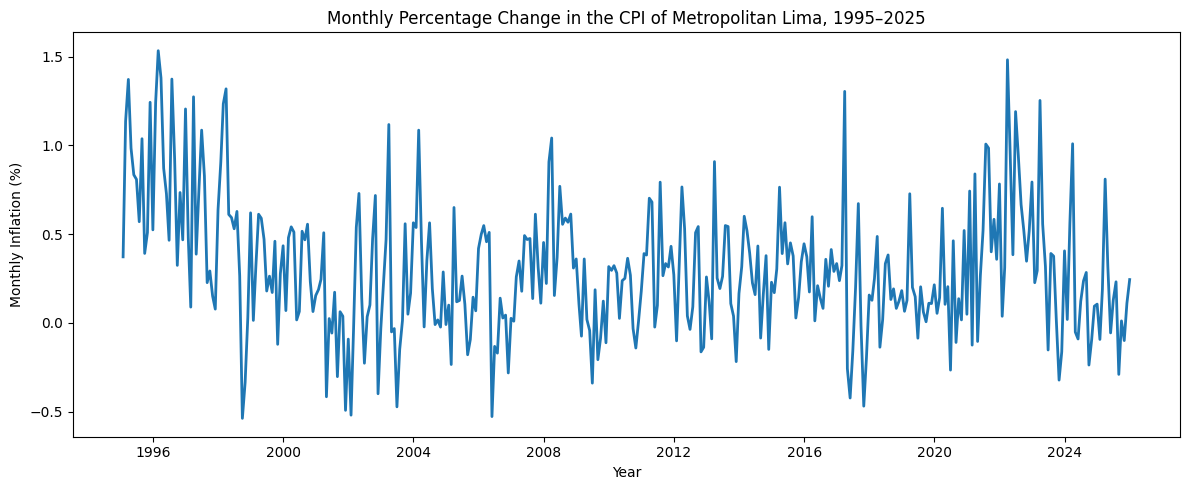

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(sarima_inf["Date"], sarima_inf["Inflation"], linewidth=2)

plt.title(plot_info["Inflation"]["title"])
plt.xlabel("Year")
plt.ylabel(plot_info["Inflation"]["ylabel"])

plt.tight_layout()
plt.show()

**Distribution of monthly inflation**

The histogram shows the frequency distribution of monthly inflation observations across the complete study period.

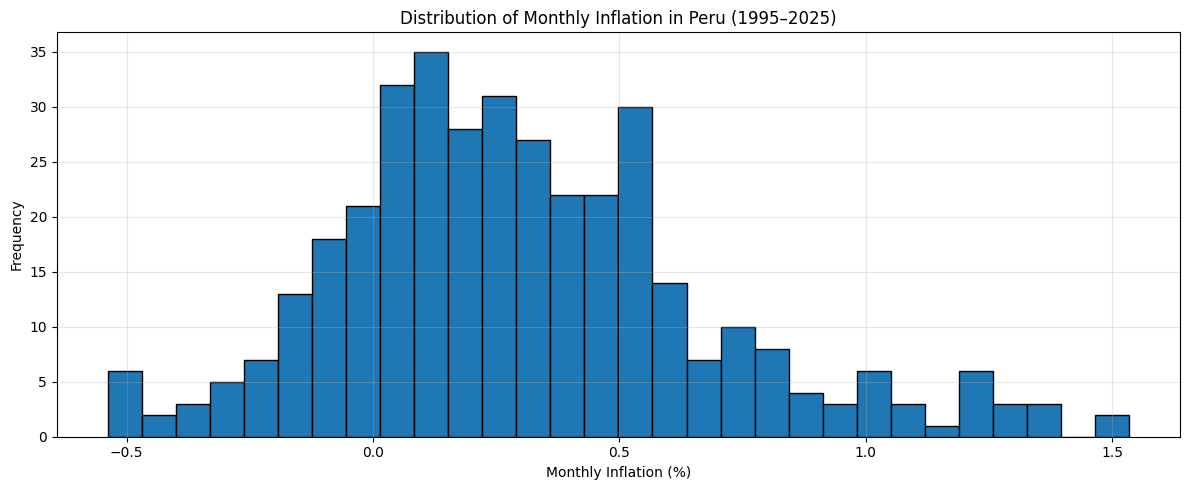

In [10]:
plt.figure(figsize=(12, 5))
plt.hist(sarima_inf["Inflation"], bins=30, edgecolor="black")

plt.title("Distribution of Monthly Inflation in Peru (1995–2025)")
plt.xlabel("Monthly Inflation (%)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Spread and potential extreme values**

The boxplot provides a compact view of the median, interquartile range and observations located beyond the whiskers. These observations are retained and are not automatically treated as data errors.

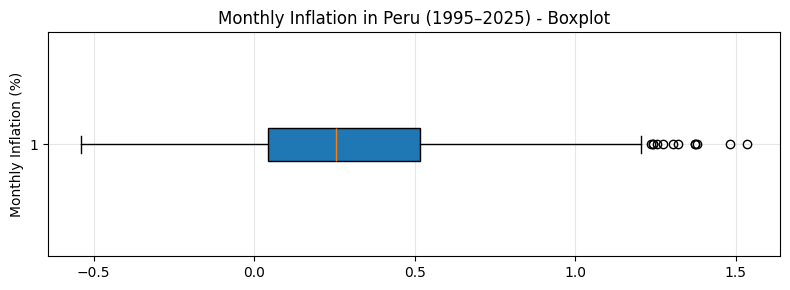

In [11]:
plt.figure(figsize=(8, 3))
plt.boxplot(sarima_inf["Inflation"], patch_artist=True, vert=False)

plt.title("Monthly Inflation in Peru (1995–2025) - Boxplot")
plt.ylabel("Monthly Inflation (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Rolling descriptive statistics**

A 12-month rolling mean and standard deviation are calculated to examine changes in the average level and variability of inflation over time. These plots are descriptive and are not used as a formal stationarity test.

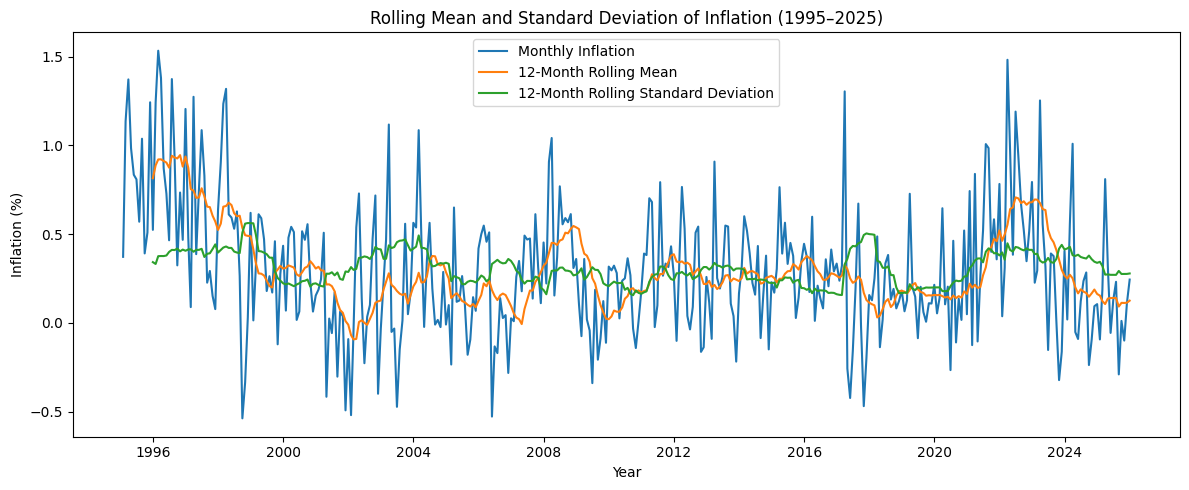

In [12]:
# Rolling statistics for the univariate inflation series

rolling_window = 12

inflation_series = sarima_inf.set_index("Date")["Inflation"]
rolling_mean = inflation_series.rolling(rolling_window).mean()
rolling_std = inflation_series.rolling(rolling_window).std()

plt.figure(figsize=(12, 5))
plt.plot(inflation_series, label="Monthly Inflation")
plt.plot(rolling_mean, label="12-Month Rolling Mean")
plt.plot(rolling_std, label="12-Month Rolling Standard Deviation")

plt.title("Rolling Mean and Standard Deviation of Inflation (1995–2025)")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.legend()

plt.tight_layout()
plt.show()

# Multivariate time-series analysis

The five variables are plotted separately because they use different measurement scales. The plots provide an initial view of their trends, fluctuations and possible changes over time.

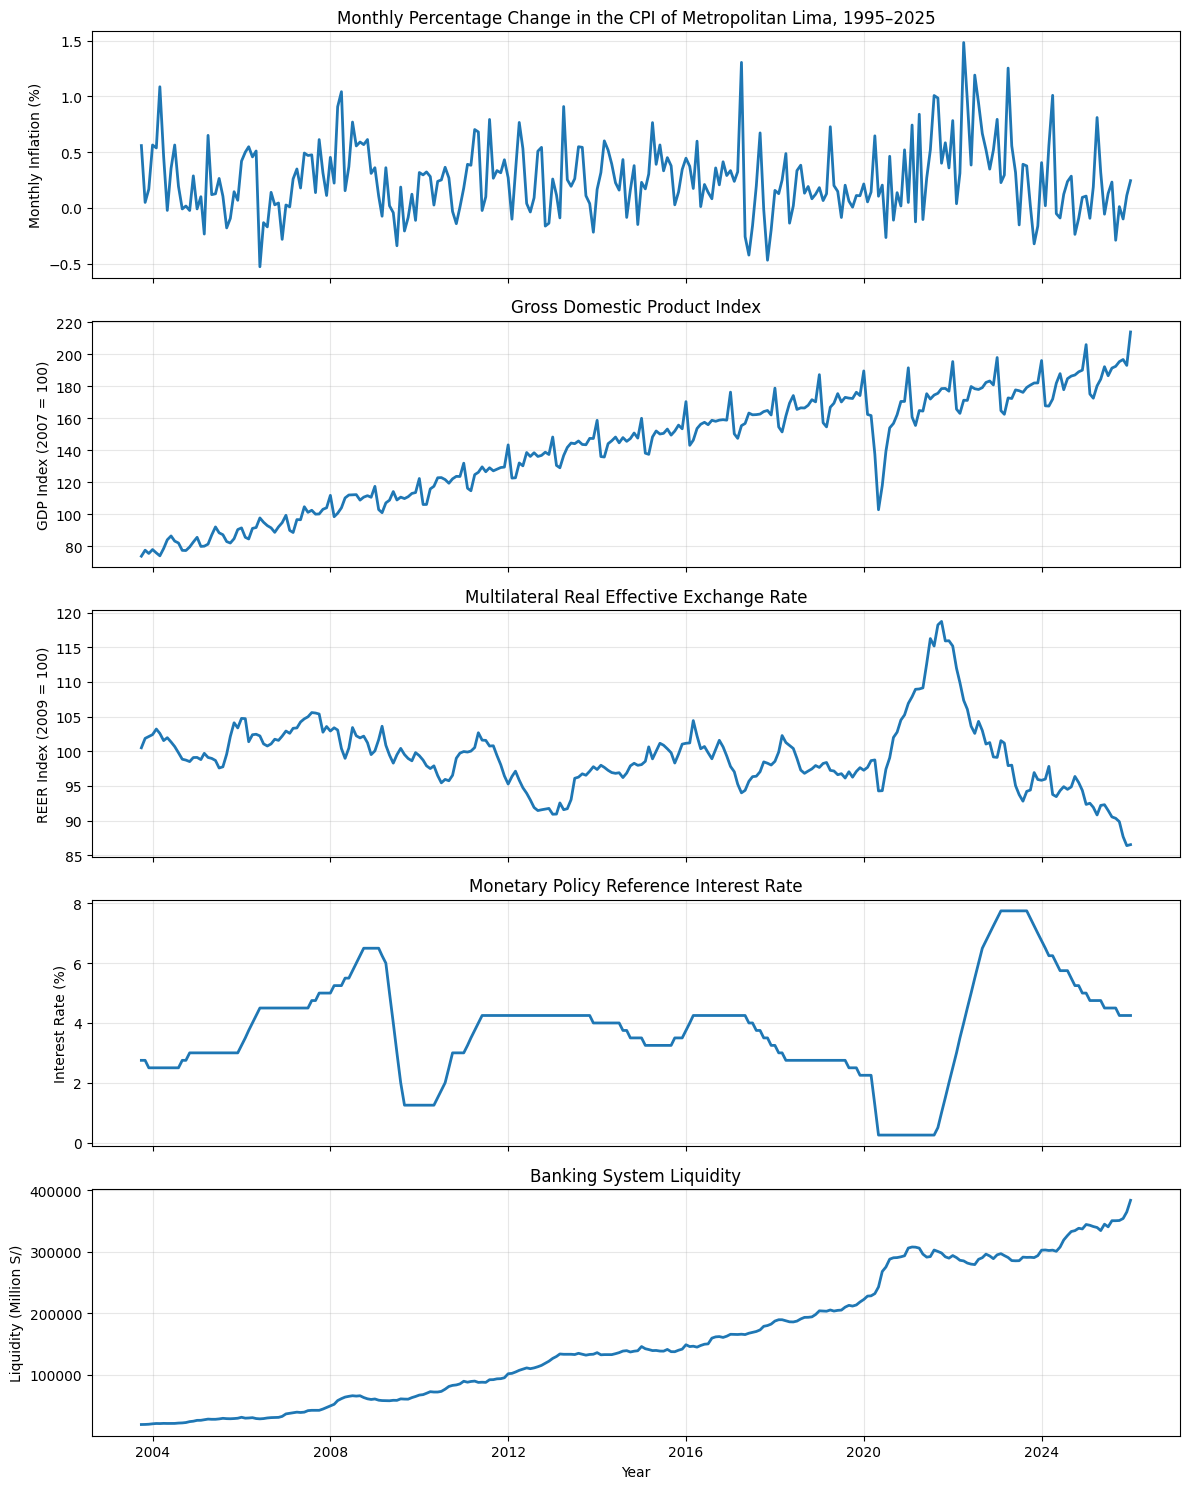

In [13]:
variables = multivar_inf.columns[1:]

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

for ax, variable in zip(axes, variables):
    ax.plot(multivar_inf["Date"], multivar_inf[variable], linewidth=2)
    ax.set_title(plot_info[variable]["title"])
    ax.set_ylabel(plot_info[variable]["ylabel"])
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Year")

plt.tight_layout()
plt.show()

**Variable distributions**

A histogram is produced for each multivariate variable to examine the shape, range and concentration of its observed values.

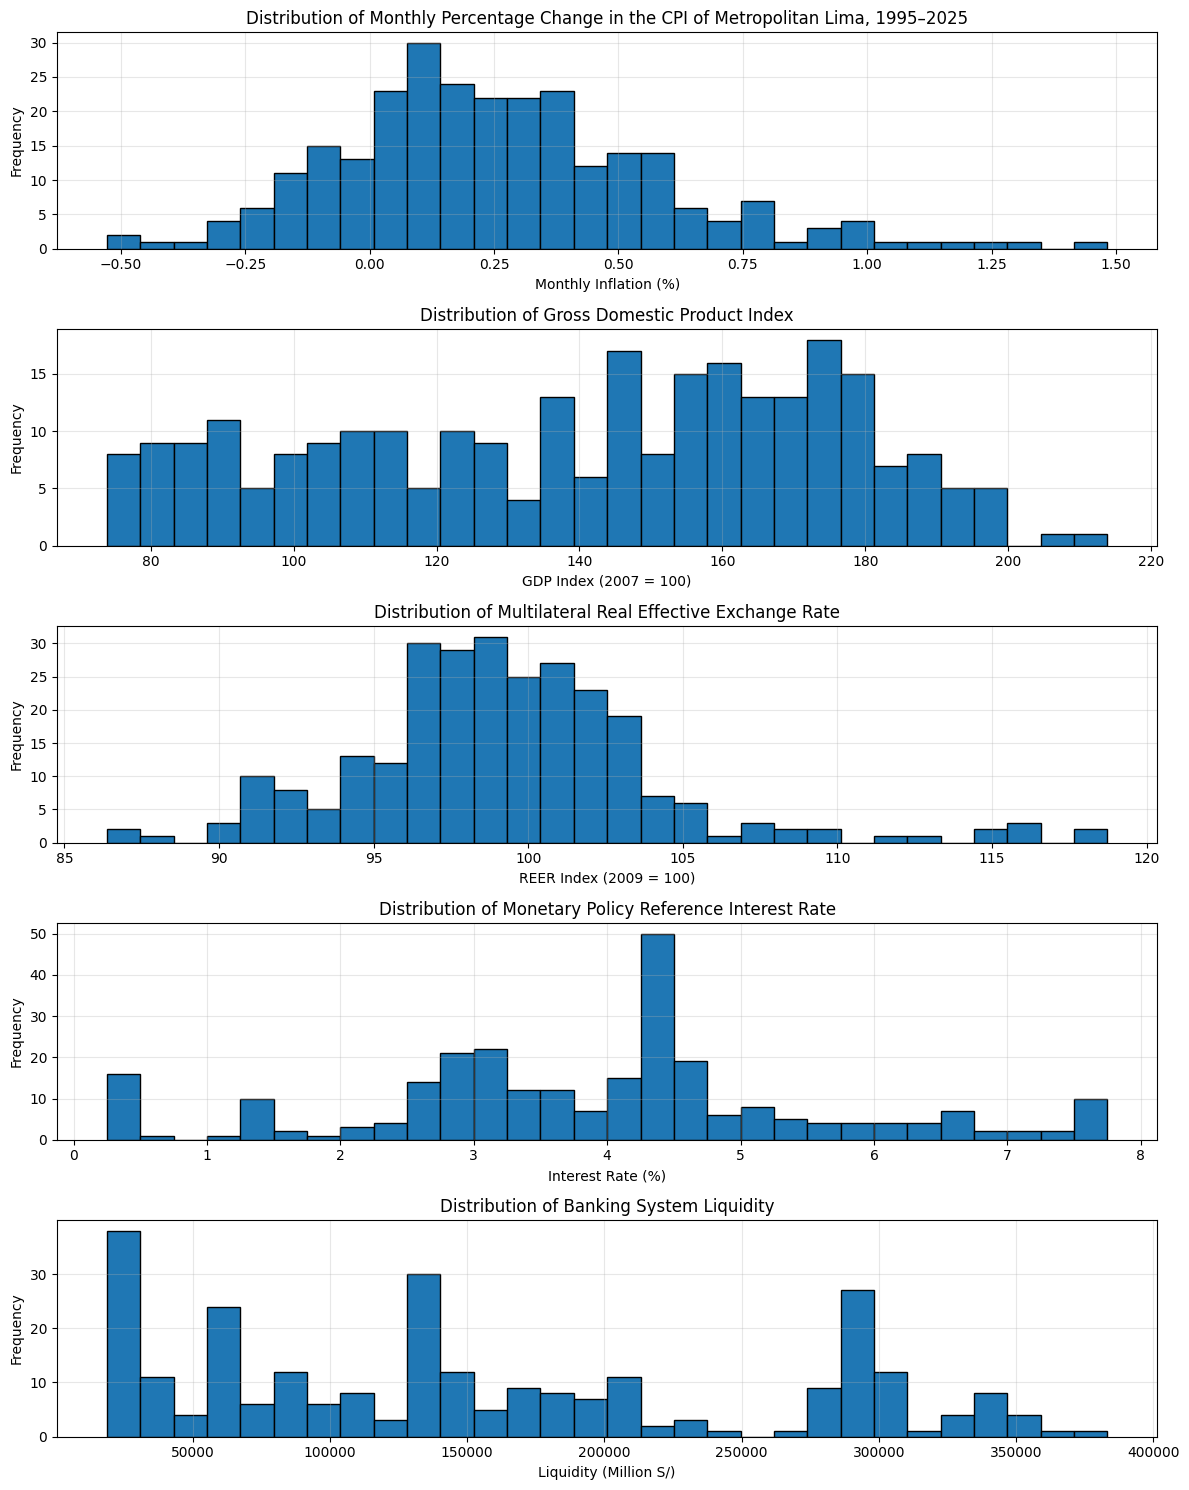

In [14]:
variables = multivar_inf.columns[1:]

fig, axes = plt.subplots(5, 1, figsize=(12, 15))

for ax, variable in zip(axes, variables):
    ax.hist(multivar_inf[variable], bins=30, edgecolor="black")
    ax.set_title("Distribution of " + plot_info[variable]["title"])
    ax.set_xlabel(plot_info[variable]["ylabel"])
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Variable spread and potential extreme values**

Separate boxplots summarise the distribution of each variable. Observations beyond the whiskers are retained because they may represent genuine economic events rather than data errors.

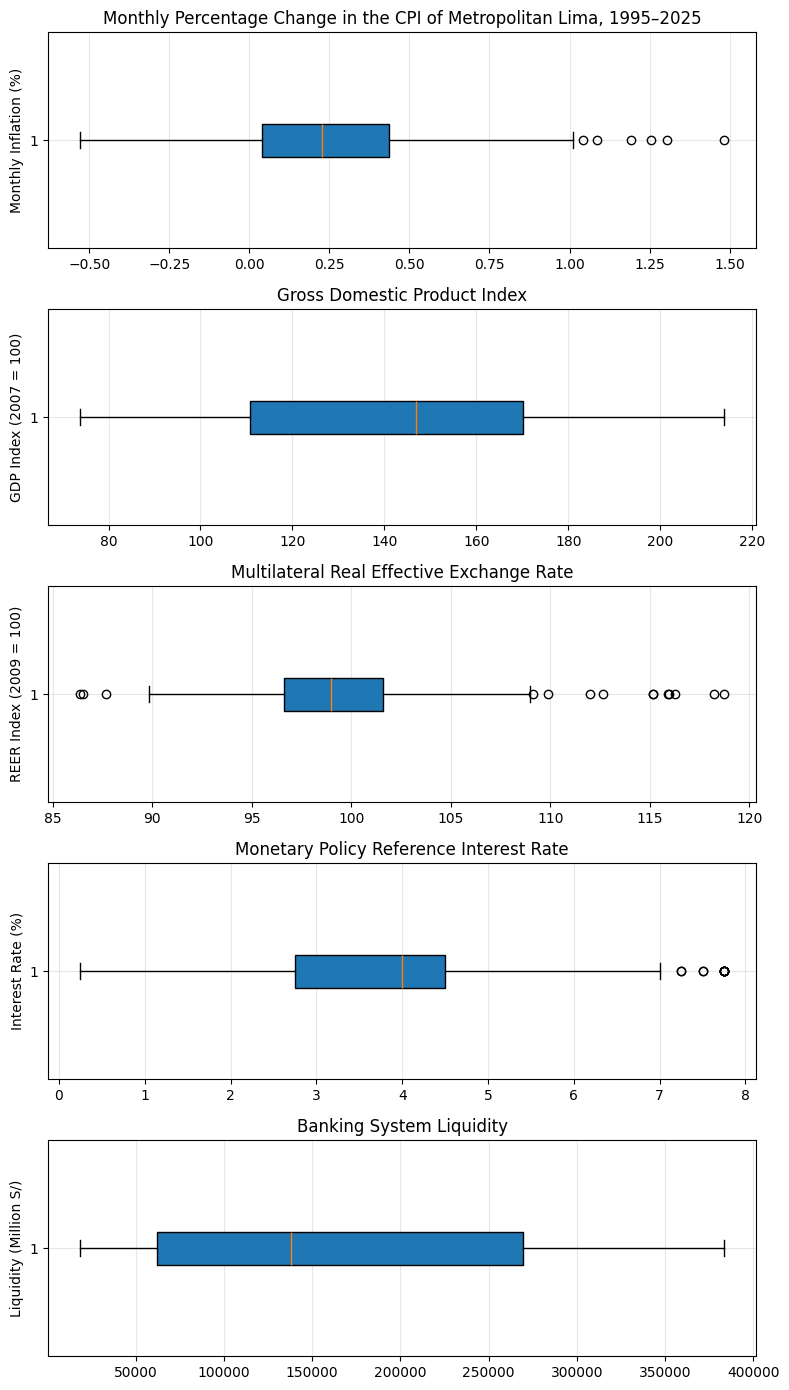

In [15]:
variables = multivar_inf.columns[1:]

fig, axes = plt.subplots(5, 1, figsize=(8, 14))

for ax, variable in zip(axes, variables):
    ax.boxplot(multivar_inf[variable], patch_artist=True, vert=False)
    ax.set_title(plot_info[variable]["title"])
    ax.set_ylabel(plot_info[variable]["ylabel"])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation analysis

Pearson correlations are calculated for the five multivariate variables in their original forms. The matrix provides a descriptive summary of their linear associations during the common study period.

Correlation does not establish causation. Some variables also contain trends at this stage, so these level correlations should be interpreted carefully. They are not used as evidence of stationarity or cointegration.

In [16]:
correlation_matrix = multivar_inf.drop(columns="Date").corr()

correlation_matrix

,Inflation,GDP,Exchange Rate,Interest,Liquidity
Inflation,1.000000,0.037213,0.272615,0.097870,0.059038
GDP,0.037213,1.000000,-0.187678,0.142731,0.909773
Exchange Rate,0.272615,-0.187678,1.000000,-0.307308,-0.116590
Interest,0.097870,0.142731,-0.307308,1.000000,0.092873
Liquidity,0.059038,0.909773,-0.116590,0.092873,1.000000


The heatmap presents each pairwise correlation once. Values closer to 1 or −1 indicate stronger positive or negative linear associations, while values closer to zero indicate weaker linear associations.

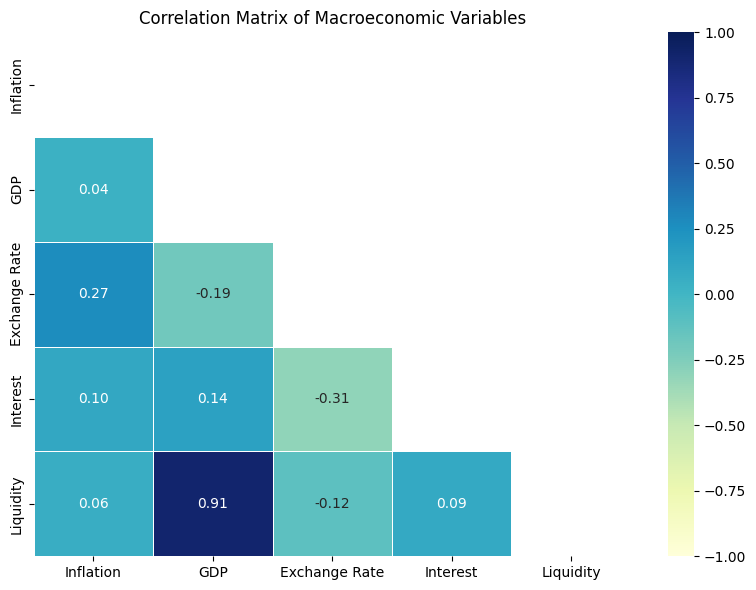

In [17]:
plt.figure(figsize=(8, 6))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Macroeconomic Variables")
plt.tight_layout()
plt.show()

**Multivariate rolling statistics**

A 12-month rolling mean and standard deviation are calculated separately for each variable. These plots help describe changes in their levels and variability but do not replace the formal stationarity tests conducted in the next notebook.

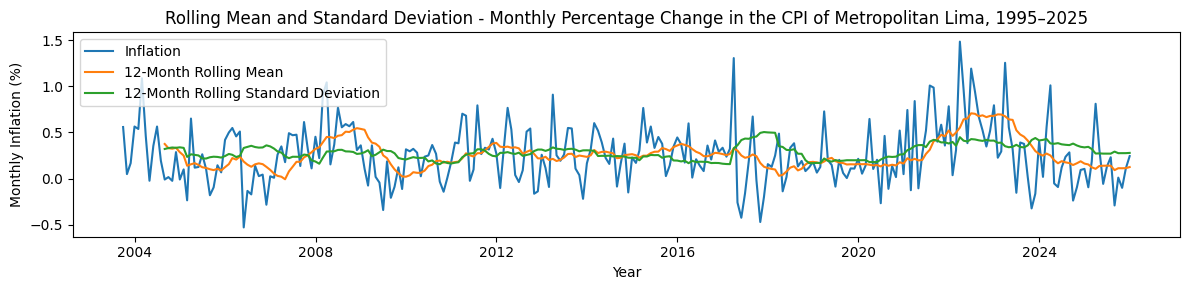

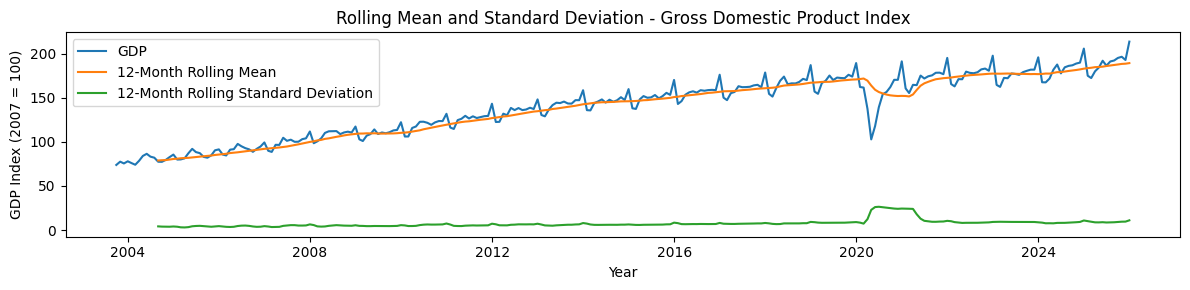

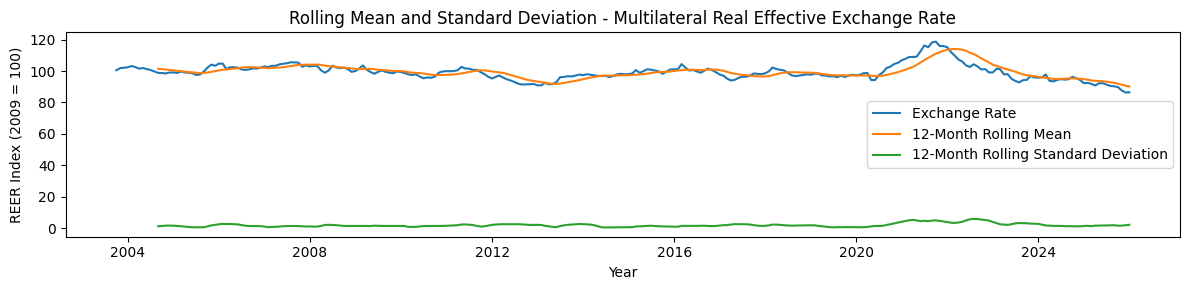

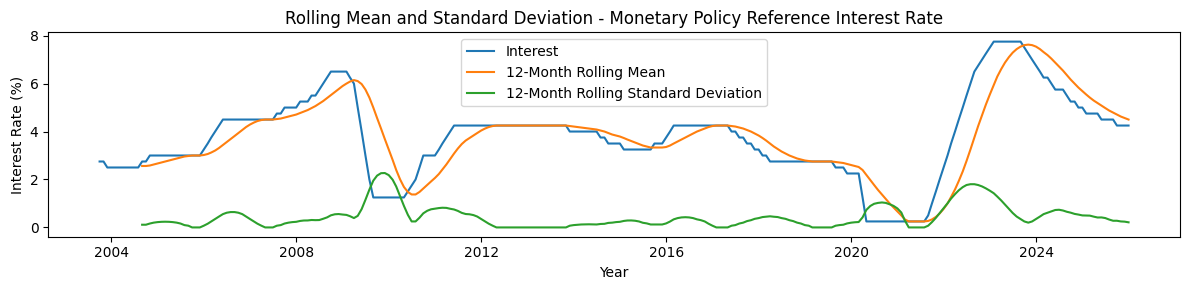

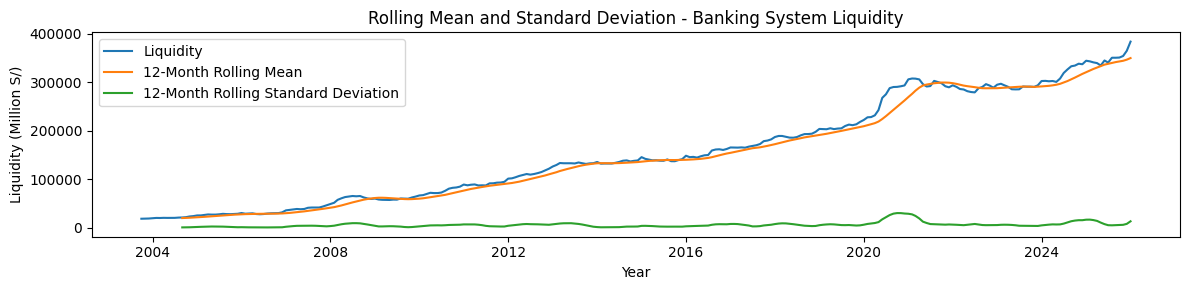

In [18]:
# Rolling statistics for the multivariate series

rolling_window = 12
multivar_series = multivar_inf.set_index("Date")

for column in multivar_series.columns:
    rolling_mean = multivar_series[column].rolling(rolling_window).mean()
    rolling_std = multivar_series[column].rolling(rolling_window).std()

    plt.figure(figsize=(12, 3))
    plt.plot(multivar_series[column], label=column)
    plt.plot(rolling_mean, label="12-Month Rolling Mean")
    plt.plot(rolling_std, label="12-Month Rolling Standard Deviation")

    plt.title("Rolling Mean and Standard Deviation - " + plot_info[column]["title"])
    plt.xlabel("Year")
    plt.ylabel(plot_info[column]["ylabel"])
    plt.legend()

    plt.tight_layout()
    plt.show()